# VADER Sentiment Analysis

## Objective

The objective of this notebook is to perform sentiment analysis on demonetization-related tweets using the VADER sentiment analyzer.

VADER is a rule-based sentiment analysis model optimized for:
- social media text
- short sentences
- informal language

The model classifies tweets into:
- Positive
- Negative
- Neutral

In [2]:
# Data Handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# VADER
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Plot Style
plt.style.use('ggplot')

print("Libraries Imported Successfully 🚀")

Libraries Imported Successfully 🚀


In [3]:
nltk.download('vader_lexicon')

print("VADER Lexicon Downloaded Successfully ✅")

VADER Lexicon Downloaded Successfully ✅


[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\rahul\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [4]:
# Load Cleaned Dataset
df = pd.read_csv("C:/Users/rahul/Desktop/demonetization-tweets.csv - Copy/demonetization-tweets.csv")

print("Dataset Loaded Successfully ✅")
print("Dataset Shape:", df.shape)

Dataset Loaded Successfully ✅
Dataset Shape: (14940, 14)


## Initialize VADER Sentiment Analyzer

The SentimentIntensityAnalyzer is initialized to calculate sentiment polarity scores for tweets.

In [5]:
# Initialize VADER
sia = SentimentIntensityAnalyzer()

print("VADER Initialized Successfully ✅")

VADER Initialized Successfully ✅


In [6]:
# Sample Tweet
sample_tweet = df['cleaned_text'][0]

print("Sample Tweet:")
print(sample_tweet)

Sample Tweet:
critical question paytm informed demonetization edict pm clearly fishy requires full disclosure amp


In [7]:
# Sentiment Scores
sia.polarity_scores(sample_tweet)

{'neg': 0.144, 'neu': 0.688, 'pos': 0.169, 'compound': 0.1027}

## Generate Sentiment Scores

VADER sentiment scores are calculated for all tweets in the dataset.

In [8]:
# Generate Sentiment Scores

sentiment_scores = df['cleaned_text'].astype(str).apply(
    lambda text: sia.polarity_scores(text)
)

print("Sentiment Scores Generated ✅")

Sentiment Scores Generated ✅


In [9]:
# Convert Scores to DataFrame

scores_df = pd.DataFrame(sentiment_scores.tolist())

scores_df.head()

,neg,neu,pos,compound
0,0.144,0.688,0.169,0.1027
1,0.000,1.000,0.000,0.0000
2,0.000,1.000,0.000,0.0000
3,0.000,1.000,0.000,0.0000
4,0.000,1.000,0.000,0.0000


In [10]:
# Merge Scores

df = pd.concat([df, scores_df], axis=1)

df.head()

,Unnamed: 0,X,text,favorited,favoriteCount,created,truncated,id,statusSource,screenName,retweetCount,isRetweet,retweeted,cleaned_text,neg,neu,pos,compound
0,1,1,RT @rssurjewala: Critical question: Was PayTM ...,False,0,2016-11-23 18:40:30,False,8.014957e+17,"<a href=""http://twitter.com/download/android"" ...",HASHTAGFARZIWAL,331,True,False,critical question paytm informed demonetizatio...,0.144,0.688,0.169,0.1027
1,2,2,RT @Hemant_80: Did you vote on #Demonetization...,False,0,2016-11-23 18:40:29,False,8.014957e+17,"<a href=""http://twitter.com/download/android"" ...",PRAMODKAUSHIK9,66,True,False,vote demonetization modi survey app,0.000,1.000,0.000,0.0000
2,3,3,"RT @roshankar: Former FinSec, RBI Dy Governor,...",False,0,2016-11-23 18:40:03,False,8.014955e+17,"<a href=""http://twitter.com/download/android"" ...",rahulja13034944,12,True,False,former finsec rbi dy governor cbdt chair harva...,0.000,1.000,0.000,0.0000
3,4,4,RT @ANI_news: Gurugram (Haryana): Post office ...,False,0,2016-11-23 18:39:59,False,8.014955e+17,"<a href=""http://twitter.com/download/android"" ...",deeptiyvd,338,True,False,gurugram haryana post office employee provide ...,0.000,1.000,0.000,0.0000
4,5,5,RT @satishacharya: Reddy Wedding! @mail_today ...,False,0,2016-11-23 18:39:39,False,8.014954e+17,"<a href=""http://cpimharyana.com"" rel=""nofollow...",CPIMBadli,120,True,False,reddy wedding cartoon demonetization reddywedding,0.000,1.000,0.000,0.0000


## Sentiment Classification

Tweets are classified into:
- Positive
- Negative
- Neutral

based on compound sentiment score.

In [11]:
# Sentiment Classification Function

def classify_sentiment(compound_score):
    
    if compound_score >= 0.05:
        return 'Positive'
    
    elif compound_score <= -0.05:
        return 'Negative'
    
    else:
        return 'Neutral'

In [12]:
# Apply Sentiment Classification

df['sentiment'] = df['compound'].apply(classify_sentiment)

print("Sentiment Classification Completed ✅")

Sentiment Classification Completed ✅


In [13]:
# Display Sentiment Counts

df['sentiment'].value_counts()

sentiment
Positive    6468
Neutral     4469
Negative    4003
Name: count, dtype: int64

## Sentiment Distribution Visualization

This section visualizes the distribution of:
- positive tweets
- negative tweets
- neutral tweets

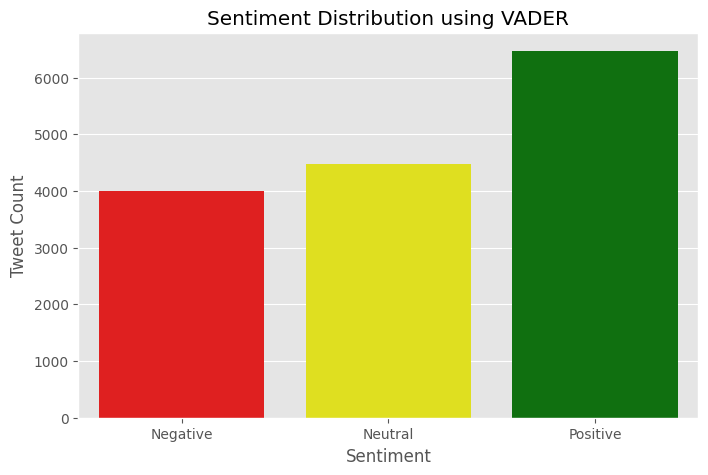

In [14]:
# Plot Sentiment Distribution

plt.figure(figsize=(8,5))

sns.countplot(
    x='sentiment',
    data=df,
    order=['Negative', 'Neutral', 'Positive'],
    palette={
        'Negative': 'red',
        'Neutral': 'yellow',
        'Positive': 'green'
    }
)

plt.title("Sentiment Distribution using VADER")
plt.xlabel("Sentiment")
plt.ylabel("Tweet Count")

plt.show()

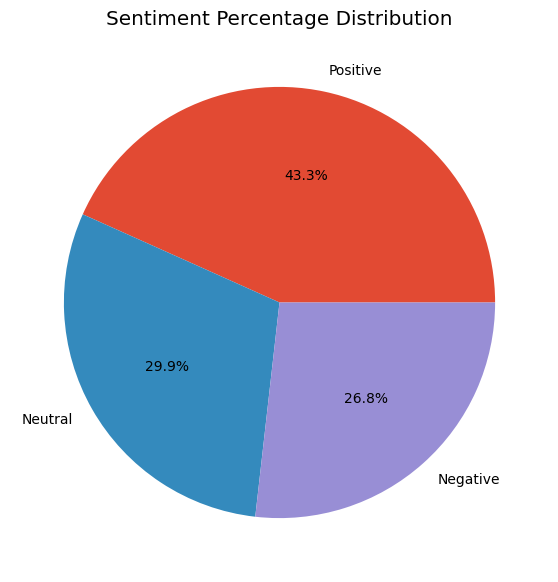

In [15]:
# Pie Chart

sentiment_counts = df['sentiment'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    sentiment_counts,
    labels=sentiment_counts.index,
    autopct='%1.1f%%'
)

plt.title("Sentiment Percentage Distribution")

plt.show()

In [16]:
# Save Dataset

df.to_csv("../data/vader_sentiment_results.csv", index=False)

print("VADER Results Saved Successfully ✅")

VADER Results Saved Successfully ✅
